In [84]:
from nrem_sc.constants import PROCESSED_DATA_PATH

import re
import numpy as np
import pynapple as nap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

unit_id = '116b'
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)
palette = ["#d73939", "#1d0505ff"]

# Load data
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

def load_decoded(save_dir):
    # Sort files by interval in filename
    paths = sorted(save_dir.glob("*.npz"), key=lambda p: int(re.findall(r'\d+', p.stem)[-2]))
    # Load and concatenate dataframes
    dfs = []
    for p in paths:
        print(f"Loading: {p.name}")
        dfs.append(nap.load_file(p).as_dataframe())
    tdf = pd.concat(dfs)
    return tdf


def extract_sweeps(tdf, label='continuous', min_gap_ms=50):
    epochs = tdf[tdf['state'] == label].find_support(min_gap=min_gap_ms, time_units='ms')
    
    if len(epochs) == 0:
        return pd.DataFrame()

    # Single restrict call for ALL epochs
    all_data = tdf.restrict(epochs)
    pos = all_data['position'].values
    times = all_data.times('s')

    # Assign each sample to its epoch via searchsorted
    starts = epochs['start']
    epoch_idx = np.searchsorted(starts, times, side='right') - 1

    # Split arrays at epoch boundaries
    split_at = np.flatnonzero(np.diff(epoch_idx)) + 1
    pos_chunks = np.split(pos, split_at)
    time_chunks = np.split(times, split_at)

    durations = np.empty(len(pos_chunks))
    net_disp  = np.empty(len(pos_chunks))
    path_len  = np.empty(len(pos_chunks))
    integral  = np.empty(len(pos_chunks))
    n_samples = np.empty(len(pos_chunks), dtype=int)

    for i, (p, t) in enumerate(zip(pos_chunks, time_chunks)):
        uw = np.unwrap(p, period=360)
        durations[i] = t[-1] - t[0]
        net_disp[i]  = np.diff(uw).sum()
        path_len[i]  = np.abs(np.diff(uw)).sum()
        integral[i]  = np.sum(p-p[0])
        n_samples[i] = len(p)

    mask = n_samples >= 2
    return pd.DataFrame({
        'duration': durations[mask],
        'net_displacement': net_disp[mask],
        'path_length': path_len[mask],
        'integral': integral[mask],
        'n_samples': n_samples[mask],
    })

### Load data

In [86]:
threshold = 0.5
save = True

dfs = []
for condition in ['pre_ttx', 'post_ttx']:
    save_dir = PROCESSED_DATA_PATH / unit_id / condition
    tdf = load_decoded(save_dir)
    
    if save:
        fname = save_dir.parent / f"{condition}_decoded_states.csv"
        print(f"Saving decoded states to: \n{fname}")
        tdf.to_csv(fname)

    # Determine the state if p>threshold, otherwise 'mixture'
    labels = tdf[['continuous', 'fragmented', 'stationary']]
    tdf['state'] = np.where(labels.max(axis=1) > threshold, labels.idxmax(axis=1), 'mixture')

    # Assign sleep state
    tdf['sleep_state'] = 'unknown'   
    for ep in sleep_states:
        start, end = ep['start'].item(), ep['end'].item()
        if start > tdf.index[-1]:
            break
        valid = (tdf.index > start) & (tdf.index < end)
        tdf.loc[valid, 'sleep_state'] = ep['state'].item()
    
    if save:
        data = nap.TsdFrame(tdf[(tdf['state'] == 'continuous') & (tdf['sleep_state'] == 'nrem')])
        fname = save_dir.parent / f"{condition}_nrem_epochs"
        print(f"Saving sweep epochs to: \n{fname}")
        data.find_support(min_gap=50, time_units='ms').save(fname)

    # Extract sweeps
    tdf = nap.TsdFrame(tdf)
    sweeps = extract_sweeps(tdf[tdf['sleep_state'] == 'nrem'], label='continuous', min_gap_ms=50)
    sweeps['condition'] = condition
    sweeps['sleep_state'] = 'nrem'
    dfs.append(sweeps)

sweeps = pd.concat(dfs)

# Partition sweeps into quartiles based on duration
sweeps['quartile'] = pd.qcut(sweeps['duration'], 4, labels=False)

# Add REM sweeps
rem_df = pd.read_csv(PROCESSED_DATA_PATH / unit_id / "decoded_rem_sweep_metrics_2s_window.csv")
rem_df['sleep_state'] = 'rem'
sweeps = pd.concat([sweeps, rem_df])

# Compute velocity
sweeps['velocity'] = sweeps['net_displacement']/sweeps['duration']

# Stats
stats = sweeps[sweeps['sleep_state'] == 'nrem']['duration'].describe()
stats

Loading: decoded1551_2551.npz
Loading: decoded2551_3551.npz
Loading: decoded3551_4551.npz
Loading: decoded4551_5551.npz
Loading: decoded5551_6551.npz
Loading: decoded6551_7551.npz
Loading: decoded7551_8551.npz
Loading: decoded8551_9551.npz
Loading: decoded9551_10551.npz
Loading: decoded10551_11551.npz
Loading: decoded11551_12551.npz
Loading: decoded12551_13551.npz
Loading: decoded13551_14551.npz
Loading: decoded14551_15551.npz
Loading: decoded15551_16551.npz
Loading: decoded16551_16644.npz
Saving decoded states to: 
D:\common_datasets\ucsf\processed\116b\pre_ttx_decoded_states.csv
Saving sweep epochs to: 
D:\common_datasets\ucsf\processed\116b\pre_ttx_nrem_epochs
Loading: decoded22244_24244.npz
Loading: decoded24244_26244.npz
Loading: decoded26244_28244.npz
Loading: decoded28244_30244.npz
Loading: decoded30244_32244.npz
Loading: decoded32244_34244.npz
Loading: decoded34244_36244.npz
Loading: decoded36244_38244.npz
Loading: decoded38244_40244.npz
Loading: decoded40244_42244.npz
Loading:

count    15330.000000
mean         0.041670
std          0.040963
min          0.002000
25%          0.012000
50%          0.028000
75%          0.060000
max          0.508000
Name: duration, dtype: float64

In [ ]:
epochs.save(PROCESSED_DATA_PATH / unit_id / "nrem_sweep_epochs.npz")
        tdf.to_csv(PROCESSED_DATA_PATH / unit_id / "post_ttx_decoded.csv")

nap.TsdFrame(tdf_post.as_dataframe().drop(columns=['state', 'sleep_state'])).save(PROCESSED_DATA_PATH / unit_id / "post_ttx_decoded.npz")

### Thresh 50

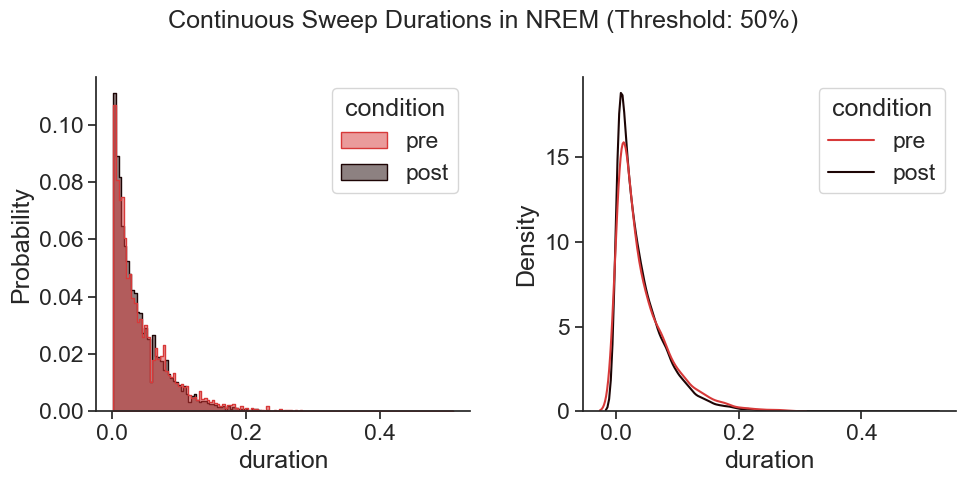

In [32]:
from nrem_sc.constants import INTERIM_DATA_PATH

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]
hist_kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)
fig.suptitle('Continuous Sweep Durations in NREM (Threshold: 50%)', fontsize=18)

axes[0] = sns.histplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='duration', hue='condition', **hist_kwargs, ax=axes[0])
# axes[0].set_xlim(-.1, 1.75)

axes[1] = sns.kdeplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='duration', hue='condition', common_norm=False, palette=palette, ax=axes[1])
# axes[1].set_xlim(-.1, 1.75)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'nrem_sweep_durations.pdf', format='pdf', dpi=1200)

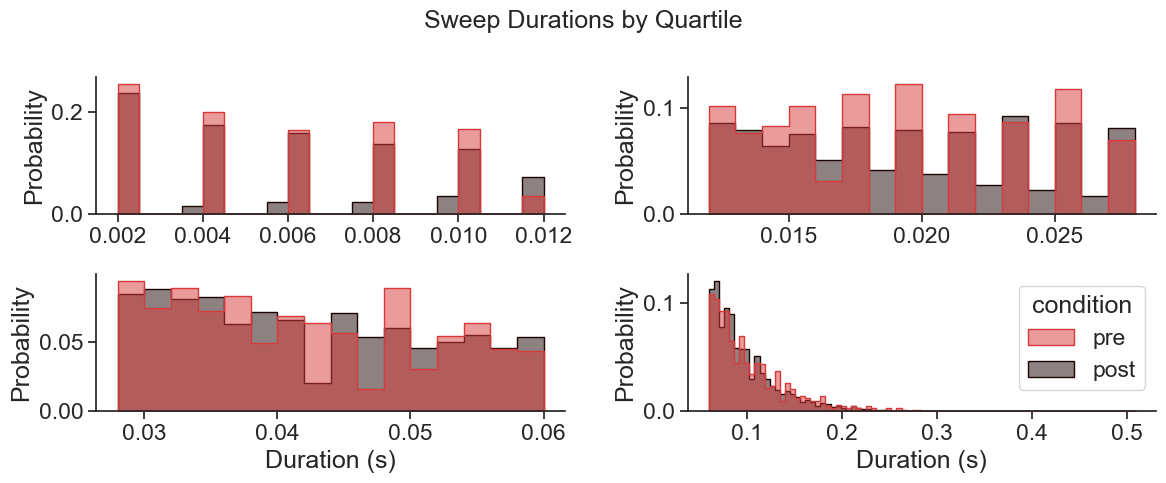

In [33]:
palette = ["#d73939", "#1d0505ff"]
kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
fig.suptitle('Sweep Durations by Quartile', fontsize=18)

axes[0, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 0], x='duration', hue='condition', **kwargs, ax=axes[0, 0], legend=False)
axes[0, 0].set_xlabel('')

axes[0, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 1], x='duration', hue='condition', **kwargs, ax=axes[0, 1], legend=False)
axes[0, 1].set_xlabel('')

axes[1, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 2], x='duration', hue='condition', **kwargs, ax=axes[1, 0], legend=False)
axes[1, 0].set_xlabel('Duration (s)')

axes[1, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 3], x='duration', hue='condition', **kwargs, ax=axes[1, 1], legend=True)
axes[1, 1].set_xlabel('Duration (s)')

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_durations_quartiles.pdf', format='pdf', dpi=1200)

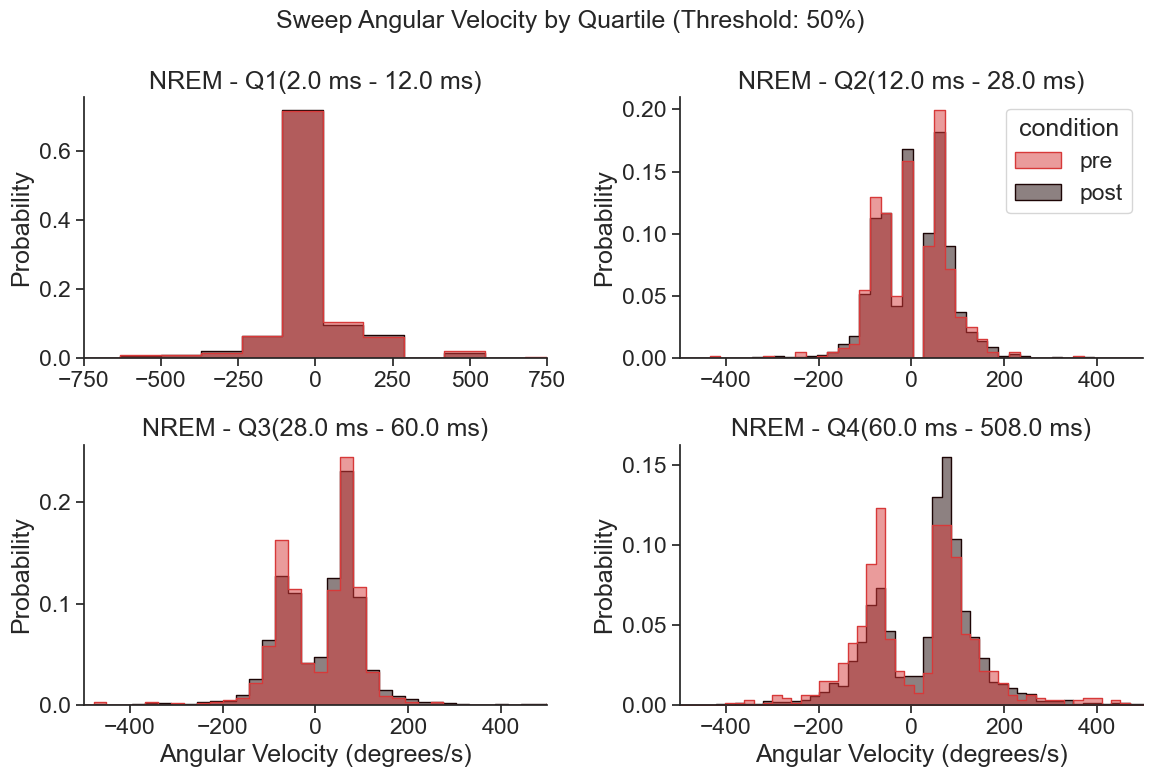

In [35]:

kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Sweep Angular Velocity by Quartile (Threshold: 50%)', fontsize=18)

axes[0, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 0], x='velocity', hue='condition', **kwargs, ax=axes[0, 0], legend=False)
axes[0, 0].set_title(f'NREM - Q1({stats["min"]*1000:.1f} ms - {stats["25%"]*1000:.1f} ms)')
axes[0, 0].set_xlabel('')
axes[0, 0].set_xlim(-750, 750)

axes[0, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 1], x='velocity', hue='condition', **kwargs, ax=axes[0, 1])
axes[0, 1].set_title(f'NREM - Q2({stats["25%"]*1000:.1f} ms - {stats["50%"]*1000:.1f} ms)')
axes[0, 1].set_xlabel('')
axes[0, 1].set_xlim(-500, 500)

axes[1, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 2], x='velocity', hue='condition', **kwargs, ax=axes[1, 0], legend=False)
axes[1, 0].set_title(f'NREM - Q3({stats["50%"]*1000:.1f} ms - {stats["75%"]*1000:.1f} ms)')
axes[1, 0].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 0].set_xlim(-500, 500)

axes[1, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 3], x='velocity', hue='condition', **kwargs, ax=axes[1, 1], legend=False)
axes[1, 1].set_title(f'NREM - Q4({stats["75%"]*1000:.1f} ms - {stats["max"]*1000:.1f} ms)')
axes[1, 1].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 1].set_xlim(-500, 500)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_velocity_quartiles_hist.pdf', format='pdf', dpi=1200)

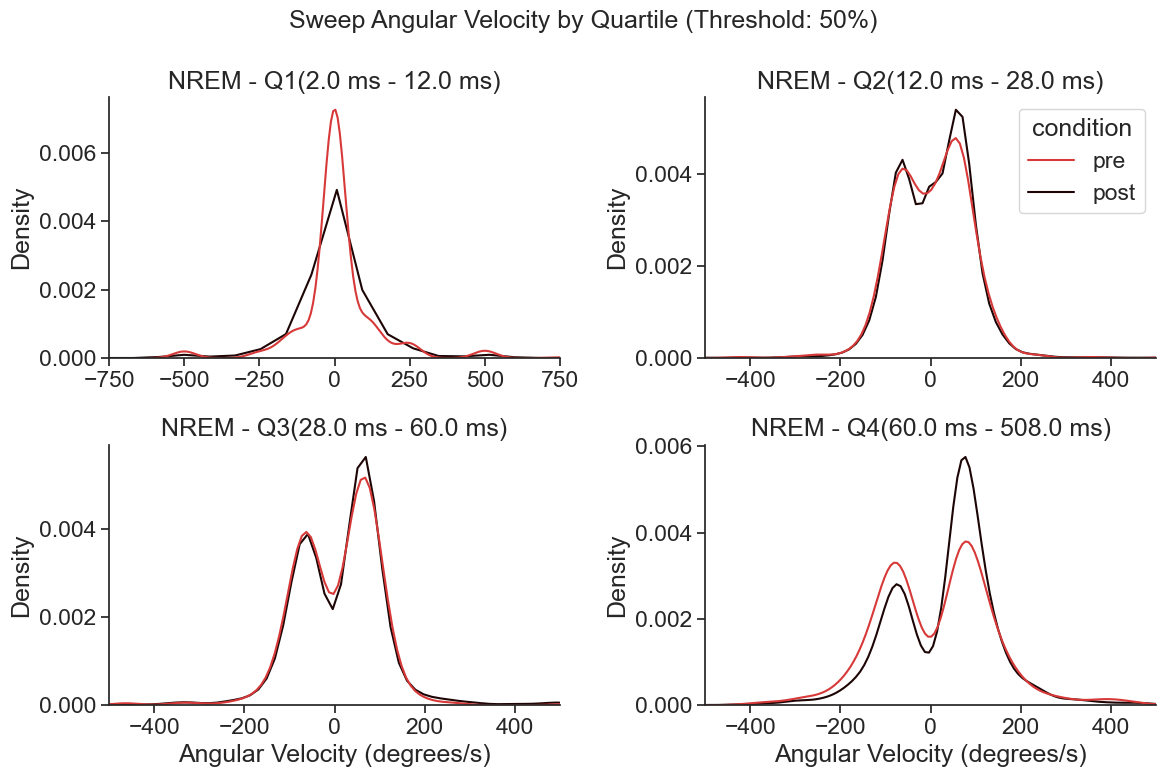

In [36]:

kwargs = dict(common_norm=False, palette=palette)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Sweep Angular Velocity by Quartile (Threshold: 50%)', fontsize=18)

axes[0, 0] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 0], x='velocity', hue='condition', **kwargs, ax=axes[0, 0], legend=False)
axes[0, 0].set_title(f'NREM - Q1({stats["min"]*1000:.1f} ms - {stats["25%"]*1000:.1f} ms)')
axes[0, 0].set_xlabel('')
axes[0, 0].set_xlim(-750, 750)

axes[0, 1] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 1], x='velocity', hue='condition', **kwargs, ax=axes[0, 1])
axes[0, 1].set_title(f'NREM - Q2({stats["25%"]*1000:.1f} ms - {stats["50%"]*1000:.1f} ms)')
axes[0, 1].set_xlabel('')
axes[0, 1].set_xlim(-500, 500)

axes[1, 0] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 2], x='velocity', hue='condition', **kwargs, ax=axes[1, 0], legend=False)
axes[1, 0].set_title(f'NREM - Q3({stats["50%"]*1000:.1f} ms - {stats["75%"]*1000:.1f} ms)')
axes[1, 0].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 0].set_xlim(-500, 500)

axes[1, 1] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 3], x='velocity', hue='condition', **kwargs, ax=axes[1, 1], legend=False)
axes[1, 1].set_title(f'NREM - Q4({stats["75%"]*1000:.1f} ms - {stats["max"]*1000:.1f} ms)')
axes[1, 1].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 1].set_xlim(-500, 500)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_velocity_quartiles_kde.pdf', format='pdf', dpi=1200)

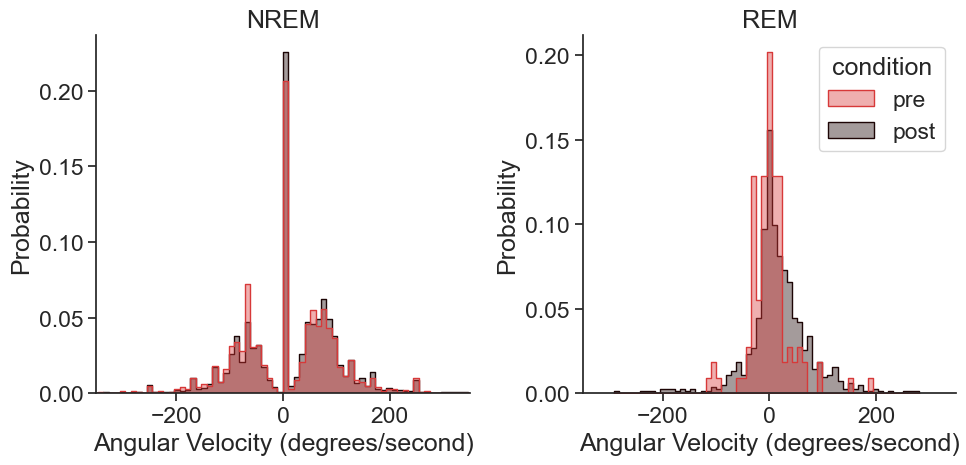

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]
kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.4, palette=palette)

mask = sweeps[sweeps['sleep_state'] == 'nrem']['velocity'].abs() < 1000
axes[0] = sns.histplot(data=(sweeps[sweeps['sleep_state'] == 'nrem'][mask]), x='velocity', hue='condition', **kwargs, ax=axes[0], legend=False)
axes[0].set_title('NREM')
axes[0].set_xlabel('Angular Velocity (degrees/second)')
axes[0].set_xlim(-350, 350)

axes[1] = sns.histplot(data=(sweeps[sweeps['sleep_state'] == 'rem']), x='velocity', hue='condition', **kwargs, ax=axes[1], legend=True)
axes[1].set_title('REM')
axes[1].set_xlabel('Angular Velocity (degrees/second)')
axes[1].set_xlim(-350, 350)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_velocity_hist.pdf', format='pdf', dpi=1200)

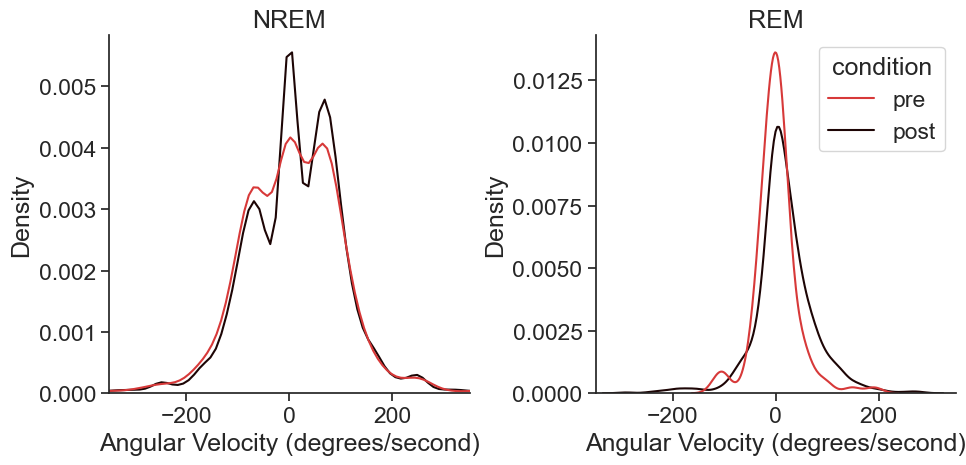

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]
kwargs = dict(common_norm=False, palette=palette)

mask = sweeps[sweeps['sleep_state'] == 'nrem']['velocity'].abs() < 1000
axes[0] = sns.kdeplot(data=(sweeps[sweeps['sleep_state'] == 'nrem'][mask]), x='velocity', hue='condition', **kwargs, ax=axes[0], legend=False)
axes[0].set_title('NREM')
axes[0].set_xlabel('Angular Velocity (degrees/second)')
axes[0].set_xlim(-350, 350)

axes[1] = sns.kdeplot(data=(sweeps[sweeps['sleep_state'] == 'rem']), x='velocity', hue='condition', **kwargs, ax=axes[1], legend=True)
axes[1].set_title('REM')
axes[1].set_xlabel('Angular Velocity (degrees/second)')
axes[1].set_xlim(-350, 350)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_velocity_kde.pdf', format='pdf', dpi=1200)

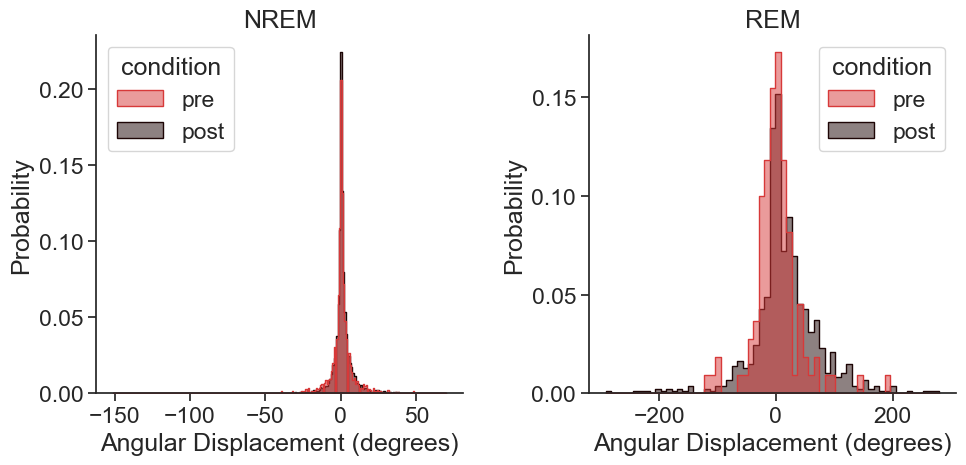

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]

hist_kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)

axes[0] = sns.histplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='net_displacement', hue='condition', **hist_kwargs, ax=axes[0])
axes[0].set_title('NREM')
axes[0].set_xlabel('Angular Displacement (degrees)')
# axes[0].set_xlim(-150, 150)

axes[1] = sns.histplot(data=sweeps[sweeps['sleep_state'] == 'rem'], x='net_displacement', hue='condition', **hist_kwargs, ax=axes[1])
axes[1].set_title('REM')
axes[1].set_xlabel('Angular Displacement (degrees)')

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_displacement_hist.pdf', format='pdf', dpi=1200)

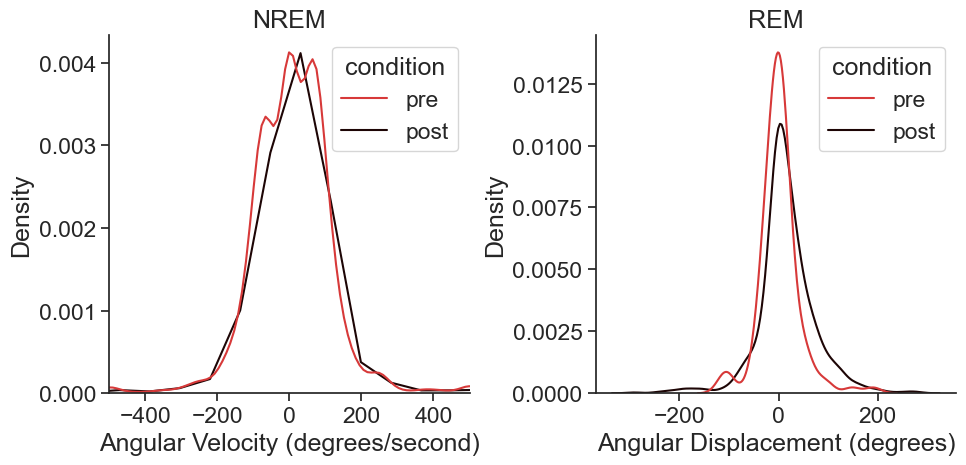

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]

kwargs = dict(common_norm=False, cumulative=False, fill=False, alpha=1, palette=palette)


# mask = sweeps[sweeps['sleep_state'] == 'nrem']['net_displacement'].abs() < 100
axes[0] = sns.kdeplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='velocity', hue='condition', **kwargs, ax=axes[0])
axes[0].set_title('NREM')
axes[0].set_xlabel('Angular Velocity (degrees/second)')
axes[0].set_xlim(-500, 500)

axes[1] = sns.kdeplot(data=sweeps[sweeps['sleep_state'] == 'rem'], x='net_displacement', hue='condition', **kwargs, ax=axes[1])
axes[1].set_title('REM')
axes[1].set_xlabel('Angular Displacement (degrees)')

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_displacement_kde.pdf', format='pdf', dpi=1200)

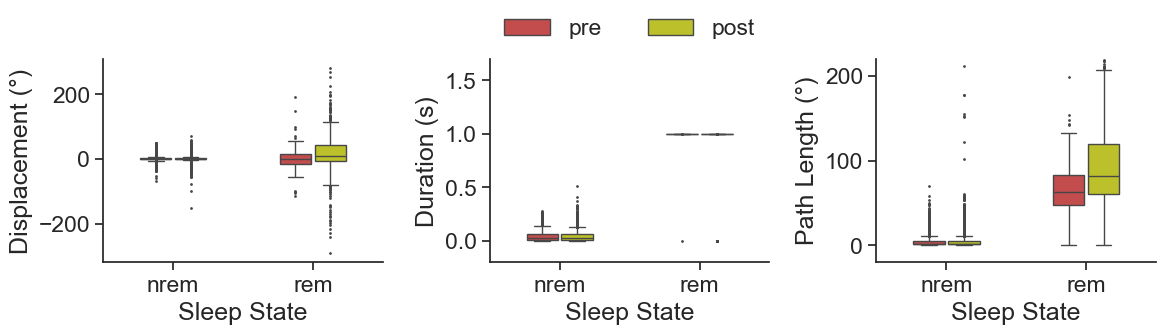

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
palette = ["#d73939", "#d3da12ff"]
box_kwargs = dict(fliersize=1, width=0.5, palette=palette, gap=0.1)

# fig.suptitle('Sweep Metrics by Sleep State', fontsize=18)

axes[0] = sns.boxplot(data=sweeps, x='sleep_state', y='net_displacement', hue='condition', **box_kwargs, ax=axes[0], legend=False)
# axes[0].set_ylim(-150, 150)
axes[0].set_ylabel('Displacement (°)')
axes[0].set_xlabel('Sleep State')

axes[1] = sns.boxplot(data=sweeps, x='sleep_state', y='duration', hue='condition', **box_kwargs, ax=axes[1])
axes[1].set_ylabel('Duration (s)')
axes[1].set_xlabel('Sleep State')
axes[1].set_ylim(-0.2, 1.7)

sns.move_legend(axes[1], "upper center", bbox_to_anchor=(0.5, 1.3),  ncol=3, title=None, frameon=False)

axes[2] = sns.boxplot(data=sweeps, x='sleep_state', y='path_length', hue='condition', **box_kwargs, ax=axes[2], legend=False)
axes[2].set_ylabel('Path Length (°)')
axes[2].set_xlabel('Sleep State')
axes[2].set_ylim(-20, 220)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_boxplots.pdf', format='pdf', dpi=1200)

### Thresh70

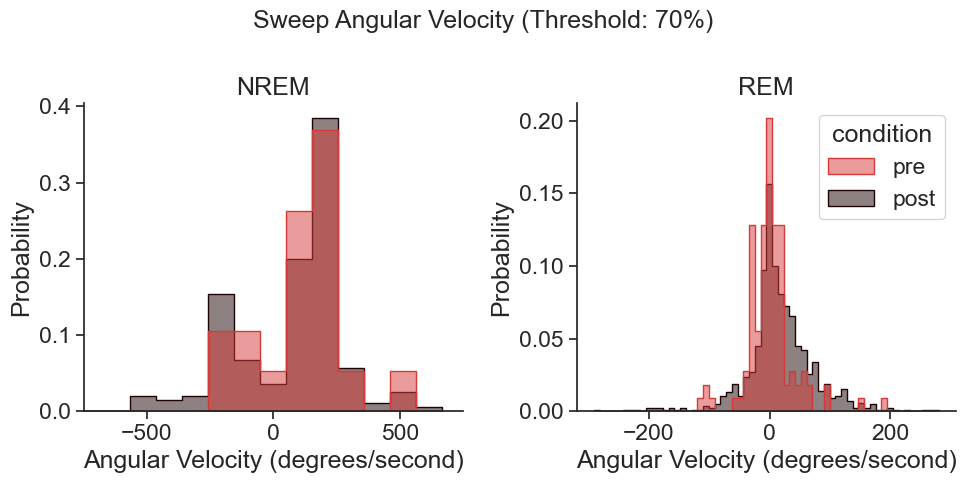

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle('Sweep Angular Velocity (Threshold: 70%)', fontsize=18)

palette = ["#d73939", "#1d0505ff"]
kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)

# mask = sweeps[sweeps['sleep_state'] == 'nrem']['velocity'].abs() < 1000
axes[0] = sns.histplot(data=(sweeps[sweeps['sleep_state'] == 'nrem']), x='velocity', hue='condition', **kwargs, ax=axes[0], legend=False)
axes[0].set_title('NREM')
axes[0].set_xlabel('Angular Velocity (degrees/second)')
axes[0].set_xlim(-750, 750)

axes[1] = sns.histplot(data=(sweeps[sweeps['sleep_state'] == 'rem']), x='velocity', hue='condition', **kwargs, ax=axes[1], legend=True)
axes[1].set_title('REM')
axes[1].set_xlabel('Angular Velocity (degrees/second)')

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_velocity_hist_thresh70.pdf', format='pdf', dpi=1200)

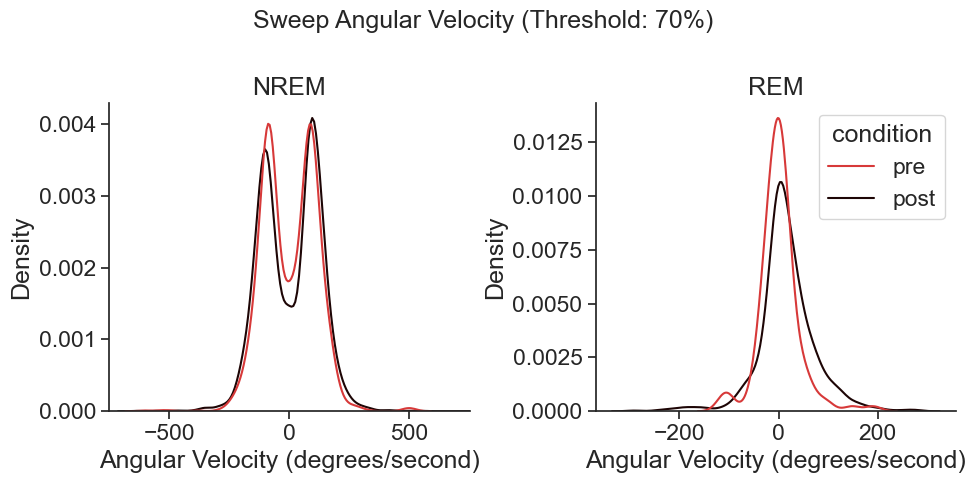

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle('Sweep Angular Velocity (Threshold: 70%)', fontsize=18)

palette = ["#d73939", "#1d0505ff"]
kwargs = dict(common_norm=False, palette=palette)

mask = sweeps[sweeps['sleep_state'] == 'nrem']['disp'].abs() < 1000
axes[0] = sns.kdeplot(data=(sweeps[sweeps['sleep_state'] == 'nrem'][mask]), x='disp', hue='condition', **kwargs, ax=axes[0], legend=False)
axes[0].set_title('NREM')
axes[0].set_xlabel('Angular Velocity (degrees/second)')
axes[0].set_xlim(-750, 750)

axes[1] = sns.kdeplot(data=(sweeps[sweeps['sleep_state'] == 'rem']), x='disp', hue='condition', **kwargs, ax=axes[1], legend=True)
axes[1].set_title('REM')
axes[1].set_xlabel('Angular Velocity (degrees/second)')

fig.tight_layout()
fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_velocity_kde_thresh70.pdf', format='pdf', dpi=1200)

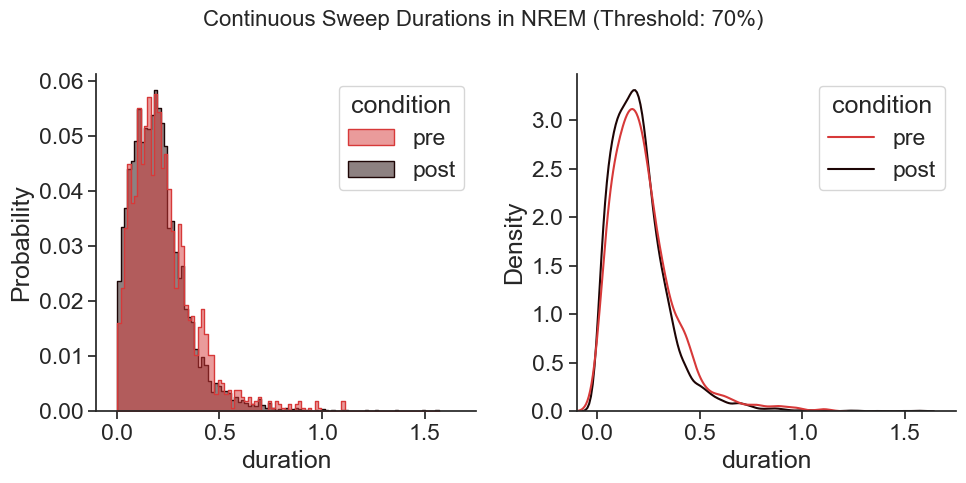

In [215]:
from nrem_sc.constants import INTERIM_DATA_PATH

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]
hist_kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)
fig.suptitle('Continuous Sweep Durations in NREM (Threshold: 70%)', fontsize=16)

axes[0] = sns.histplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='duration', hue='condition', **hist_kwargs, ax=axes[0])
axes[0].set_xlim(-.1, 1.75)

axes[1] = sns.kdeplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='duration', hue='condition', common_norm=False, palette=palette, ax=axes[1])
axes[1].set_xlim(-.1, 1.75)

fig.tight_layout()
fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'nrem_sweep_durations_thresh70.pdf', format='pdf', dpi=1200)